In [1]:
import torch
import numpy as np
import random
import os
import pickle
import time
import matplotlib.pyplot as plt
from scipy.stats import zscore, rankdata
import torch.optim

from Transformer_deepQnet import TransformerAgent
from Transformer_evaluate import do_eval, do_test

import matplotlib.pyplot as plt

In [2]:
# Core imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import os
import pickle
import time
import matplotlib.pyplot as plt
from scipy.stats import zscore, rankdata
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Custom modules
from Transformer_deepQnet import (
    TemporalVAE, TemporalVAETrainer,
    DecisionTransformer, DecisionTransformerTrainer,
    ConservativeSACAgent,
    ClinicalRLAgent, TransformerAgent
)
from Transformer_evaluate import (
    do_eval, do_test, 
    compute_wis, bootstrap_wis,
    compute_doubly_robust, bootstrap_doubly_robust,
    compute_effective_sample_size,
    compute_survival_metrics,
    comprehensive_ope,
    plot_ope_results
)

print("Modules loaded successfully!")

Modules loaded successfully!


In [3]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Enabled: {torch.backends.cudnn.enabled}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
CUDA Version: 12.1
cuDNN Enabled: True
GPU: NVIDIA GeForce GTX 1650


In [4]:
# Random seed for reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
print("Random seed set to 42")

Random seed set to 42


## Configuration

In [5]:
# =============================================================================
# HYPERPARAMETERS CONFIGURATION
# =============================================================================

config = {
    # Data
    'state_dim': 37,
    'action_dim': 2,
    'max_seq_len': 48,  # Max ICU stay length (4h intervals)
    
    # Stage 1: Temporal VAE
    'vae_latent_dim': 32,
    'vae_hidden_dim': 128,
    'vae_epochs': 50,
    'vae_lr': 1e-3,
    'vae_batch_size': 64,
    'kl_annealing_epochs': 20,
    
    # Stage 2: Decision Transformer
    'dt_d_model': 128,
    'dt_nhead': 4,
    'dt_num_layers': 3,
    'dt_epochs': 100,
    'dt_lr': 1e-4,
    'dt_batch_size': 32,
    
    # Stage 3: Conservative SAC
    'sac_hidden_dim': 256,
    'sac_epochs': 100,
    'sac_lr': 3e-4,
    'sac_batch_size': 256,
    'cql_alpha': 1.0,
    'bc_alpha': 0.5,
    
    # General
    'gamma': 0.99,
    'reward_value': 24,
    'beat': [0, 0.6, 0.3],  # [terminal, SOFA_diff, BC regularization]
    
    # Paths
    'save_dir': 'Transformer-algorithm/',
    'data_path': '../step_4_start_mimiciv_try.pkl'
}

# Create save directory
os.makedirs(config['save_dir'], exist_ok=True)
print("Configuration loaded:")
for k, v in config.items():
    print(f"  {k}: {v}")

Configuration loaded:
  state_dim: 37
  action_dim: 2
  max_seq_len: 48
  vae_latent_dim: 32
  vae_hidden_dim: 128
  vae_epochs: 50
  vae_lr: 0.001
  vae_batch_size: 64
  kl_annealing_epochs: 20
  dt_d_model: 128
  dt_nhead: 4
  dt_num_layers: 3
  dt_epochs: 100
  dt_lr: 0.0001
  dt_batch_size: 32
  sac_hidden_dim: 256
  sac_epochs: 100
  sac_lr: 0.0003
  sac_batch_size: 256
  cql_alpha: 1.0
  bc_alpha: 0.5
  gamma: 0.99
  reward_value: 24
  beat: [0, 0.6, 0.3]
  save_dir: Transformer-algorithm/
  data_path: ../step_4_start_mimiciv_try.pkl


## Data Loading and Preprocessing

In [6]:
# =============================================================================
# LOAD MIMIC-IV DATA
# =============================================================================

start = time.perf_counter()

# Load main data
with open(config['data_path'], 'rb') as file:
    MIMICtable = pickle.load(file)

print(f"Loaded data shape: {MIMICtable.shape}")
print(f"Columns: {MIMICtable.columns.tolist()[:10]}...")

icustayidlist = MIMICtable['stay_id']
icuuniqueids = np.unique(icustayidlist)
reformat5 = MIMICtable.values.copy()

print(f"Unique ICU stays: {len(icuuniqueids)}")

Loaded data shape: (474660, 59)
Columns: ['bloc', 'stay_id', 'charttime', 'gender', 'age', 'elixhauser', 're_admission', 'died_in_hosp', 'died_within_48h_of_out_time', 'mortality_90d']...
Unique ICU stays: 35608


In [7]:
# =============================================================================
# FEATURE NORMALIZATION
# =============================================================================

# 29 standard normalized features
colnorm = ['SOFA', 'age', 'Weight_kg', 'GCS', 'HR', 'SysBP', 'MeanBP', 'DiaBP', 'RR', 'Temp_C',
           'Sodium', 'Chloride', 'Glucose', 'Calcium', 'Hb', 'WBC_count', 'Platelets_count',
           'PTT', 'PT', 'Arterial_pH', 'paO2', 'paCO2', 'HCO3', 'Arterial_lactate', 'Shock_Index',
           'PaO2_FiO2', 'cumulated_balance', 'CO2_mEqL', 'Ionised_Ca']

# 8 log-transformed features
collog = ['SpO2', 'BUN', 'Creatinine', 'SGOT',
          'Total_bili', 'INR', 'input_total', 'output_total']

colnorm_idx = np.where(np.isin(MIMICtable.columns, colnorm))[0]
collog_idx = np.where(np.isin(MIMICtable.columns, collog))[0]

scaleMIMIC = np.concatenate([
    zscore(reformat5[:, colnorm_idx], ddof=1),
    zscore(np.log(0.1 + reformat5[:, collog_idx]), ddof=1)
], axis=1)

print(f"Scaled features shape: {scaleMIMIC.shape}")
print(f"Feature statistics - mean: {scaleMIMIC.mean():.4f}, std: {scaleMIMIC.std():.4f}")

Scaled features shape: (474660, 37)
Feature statistics - mean: 0.0000, std: 1.0000


In [8]:
# =============================================================================
# TRAIN/VALIDATION/TEST SPLIT
# =============================================================================

train_idx = np.load('train_mimiciv_exp.npy')
valid_idx = np.load('validation_mimiciv_exp.npy')
test_idx = np.load('test_mimiciv_exp.npy')

# States
Xtrain = scaleMIMIC[train_idx, :]
Xvalid = scaleMIMIC[valid_idx, :]
Xtest = scaleMIMIC[test_idx, :]

# Block identifiers (episode boundaries)
blocstrain = reformat5[train_idx, 0]
blocsvalid = reformat5[valid_idx, 0]
blocstest = reformat5[test_idx, 0]

# Patient IDs
ptidtrain = reformat5[train_idx, 1]
ptidvalid = reformat5[valid_idx, 1]
ptidtest = reformat5[test_idx, 1]

print(f"Train: {len(train_idx)} samples")
print(f"Valid: {len(valid_idx)} samples")
print(f"Test: {len(test_idx)} samples")

Train: 474660 samples
Valid: 474660 samples
Test: 474660 samples


In [9]:
# =============================================================================
# ACTION PROCESSING (Continuous IV & Vasopressor)
# =============================================================================

iol = MIMICtable.columns.get_loc('input_4hourly')  # IV fluid
vcl = MIMICtable.columns.get_loc('max_dose_vaso')  # Vasopressor

iv_raw = reformat5[:, iol].reshape(-1, 1)
vaso_raw = reformat5[:, vcl].reshape(-1, 1)

# Log1p transform for better distribution
iv_log = np.log1p(iv_raw)
vaso_log = np.log1p(vaso_raw)

# Z-score normalization
mean_log_iv, std_log_iv = iv_log.mean(), iv_log.std(ddof=1)
mean_log_vaso, std_log_vaso = vaso_log.mean(), vaso_log.std(ddof=1)

iv_norm = (iv_log - mean_log_iv) / std_log_iv
vaso_norm = (vaso_log - mean_log_vaso) / std_log_vaso

continuous_actions = np.concatenate([iv_norm, vaso_norm], axis=1)

# Save normalization stats
norm_stats = {
    "mean_log_iv": float(mean_log_iv),
    "std_log_iv": float(std_log_iv),
    "mean_log_vaso": float(mean_log_vaso),
    "std_log_vaso": float(std_log_vaso)
}
with open(f"{config['save_dir']}/action_norm_stats.pkl", 'wb') as f:
    pickle.dump(norm_stats, f)

# Split actions
actionbloctrain = continuous_actions[train_idx]
actionblocvalid = continuous_actions[valid_idx]
actionbloctest = continuous_actions[test_idx]

print(f"Action stats - IV: mean={mean_log_iv:.3f}, std={std_log_iv:.3f}")
print(f"Action stats - Vaso: mean={mean_log_vaso:.3f}, std={std_log_vaso:.3f}")

Action stats - IV: mean=3.342, std=2.578
Action stats - Vaso: mean=0.041, std=0.138


In [10]:
# =============================================================================
# REWARD COMPUTATION
# =============================================================================

outcome_col = 9  # 90-day mortality
sofa_col = 57

# Training outcomes
Y90_train = reformat5[train_idx, outcome_col]
SOFA_train = reformat5[train_idx, sofa_col]

# Terminal reward: +/- reward_value based on survival
reward_value = config['reward_value']
r = np.array([reward_value, -reward_value]).reshape(1, -1)
r2 = r * (2 * (1 - Y90_train.reshape(-1, 1)) - 1)
R_terminal = r2[:, 0]  # +24 for survival, -24 for death

# Validation/Test outcomes
Y90_valid = reformat5[valid_idx, outcome_col]
Y90_test = reformat5[test_idx, outcome_col]
SOFA_valid = reformat5[valid_idx, sofa_col]
SOFA_test = reformat5[test_idx, sofa_col]

print(f"90-day Mortality Rate:")
print(f"  Train: {Y90_train.mean()*100:.1f}%")
print(f"  Valid: {Y90_valid.mean()*100:.1f}%")
print(f"  Test: {Y90_test.mean()*100:.1f}%")

90-day Mortality Rate:
  Train: 26.7%
  Valid: 26.6%
  Test: 26.4%


## Generate Trajectories for Sequential Models

In [11]:
# =============================================================================
# TRAJECTORY GENERATION (Transition-level)
# =============================================================================

def generate_transitions(
    states: np.ndarray,
    actions: np.ndarray,
    blocks: np.ndarray,
    sofa: np.ndarray,
    terminal_rewards: np.ndarray,
    beat: List[float]
) -> Dict[str, np.ndarray]:
    """Generate transition tuples (s, a, r, s', done)."""
    
    beat1, beat2, _ = beat
    n_samples = len(states)
    
    # Pre-allocate arrays
    states_out = np.zeros((n_samples, states.shape[1]))
    actions_out = np.zeros((n_samples, actions.shape[1]))
    next_states_out = np.zeros((n_samples, states.shape[1]))
    next_actions_out = np.zeros((n_samples, actions.shape[1]))
    rewards_out = np.zeros(n_samples)
    dones_out = np.zeros(n_samples)
    bloc_nums = np.zeros(n_samples)
    
    c = 0
    bloc_num = 1
    
    for i in range(n_samples - 1):
        states_out[c] = states[i]
        actions_out[c] = actions[i]
        bloc_nums[c] = bloc_num
        
        if blocks[i + 1] == 1:  # Episode boundary
            next_states_out[c] = np.zeros(states.shape[1])
            next_actions_out[c] = -1
            dones_out[c] = 1
            rewards_out[c] = -beat1 * sofa[i] + terminal_rewards[i]
            bloc_num += 1
        else:
            next_states_out[c] = states[i + 1]
            next_actions_out[c] = actions[i + 1]
            dones_out[c] = 0
            rewards_out[c] = -beat2 * (sofa[i + 1] - sofa[i])
        
        c += 1
    
    # Handle last sample
    states_out[c] = states[c]
    actions_out[c] = actions[c]
    bloc_nums[c] = bloc_num
    next_states_out[c] = np.zeros(states.shape[1])
    next_actions_out[c] = -1
    dones_out[c] = 1
    rewards_out[c] = -beat1 * sofa[c] + terminal_rewards[c]
    c += 1
    
    return {
        'states': states_out[:c],
        'actions': actions_out[:c],
        'rewards': rewards_out[:c],
        'next_states': next_states_out[:c],
        'next_actions': next_actions_out[:c],
        'dones': dones_out[:c],
        'bloc_nums': bloc_nums[:c]
    }

print("Generating training transitions...")
train_data = generate_transitions(
    Xtrain, actionbloctrain, blocstrain, SOFA_train, R_terminal, config['beat']
)
print(f"Generated {len(train_data['states'])} transitions")
print(f"Number of episodes: {int(train_data['bloc_nums'].max())}")

Generating training transitions...
Generated 380248 transitions
Number of episodes: 28486


In [12]:
# =============================================================================
# TRAJECTORY GENERATION (Episode-level for Decision Transformer)
# =============================================================================

def generate_episodes(
    states: np.ndarray,
    actions: np.ndarray,
    rewards: np.ndarray,
    dones: np.ndarray,
    bloc_nums: np.ndarray,
    max_len: int = 48
) -> List[Dict[str, np.ndarray]]:
    """Generate episode sequences for Decision Transformer."""
    
    episodes = []
    unique_blocs = np.unique(bloc_nums)
    
    for bloc in unique_blocs:
        mask = bloc_nums == bloc
        ep_states = states[mask]
        ep_actions = actions[mask]
        ep_rewards = rewards[mask]
        ep_dones = dones[mask]
        
        # Compute returns-to-go
        ep_returns = np.zeros_like(ep_rewards)
        running_return = 0
        for t in reversed(range(len(ep_rewards))):
            running_return = ep_rewards[t] + config['gamma'] * running_return
            ep_returns[t] = running_return
        
        # Pad or truncate to max_len
        T = len(ep_states)
        if T > max_len:
            ep_states = ep_states[:max_len]
            ep_actions = ep_actions[:max_len]
            ep_returns = ep_returns[:max_len]
            ep_rewards = ep_rewards[:max_len]
            timesteps = np.arange(max_len)
            mask_seq = np.ones(max_len)
        else:
            pad_len = max_len - T
            ep_states = np.pad(ep_states, ((0, pad_len), (0, 0)))
            ep_actions = np.pad(ep_actions, ((0, pad_len), (0, 0)))
            ep_returns = np.pad(ep_returns, (0, pad_len))
            ep_rewards = np.pad(ep_rewards, (0, pad_len))
            timesteps = np.pad(np.arange(T), (0, pad_len))
            mask_seq = np.pad(np.ones(T), (0, pad_len))
        
        episodes.append({
            'states': ep_states,
            'actions': ep_actions,
            'returns': ep_returns,
            'rewards': ep_rewards,
            'timesteps': timesteps,
            'mask': mask_seq
        })
    
    return episodes

print("Generating episode sequences...")
episodes = generate_episodes(
    train_data['states'],
    train_data['actions'],
    train_data['rewards'],
    train_data['dones'],
    train_data['bloc_nums'],
    max_len=config['max_seq_len']
)
print(f"Generated {len(episodes)} episodes")

# Episode length statistics
ep_lengths = [ep['mask'].sum() for ep in episodes]
print(f"Episode length: mean={np.mean(ep_lengths):.1f}, max={max(ep_lengths)}, min={min(ep_lengths)}")

Generating episode sequences...
Generated 28486 episodes
Episode length: mean=13.3, max=20.0, min=1.0


In [13]:
# =============================================================================
# CONVERT TO TENSORS
# =============================================================================

# Transition-level tensors (for SAC)
state_t = torch.FloatTensor(train_data['states']).to(device)
next_state_t = torch.FloatTensor(train_data['next_states']).to(device)
action_t = torch.FloatTensor(train_data['actions']).to(device)
next_action_t = torch.FloatTensor(train_data['next_actions']).to(device)
reward_t = torch.FloatTensor(train_data['rewards']).to(device)
done_t = torch.FloatTensor(train_data['dones']).to(device)
bloc_num_t = train_data['bloc_nums']

batchs = (state_t, next_state_t, action_t, next_action_t, reward_t, done_t, bloc_num_t, SOFA_train)

print(f"State tensor shape: {state_t.shape}")
print(f"Action tensor shape: {action_t.shape}")

State tensor shape: torch.Size([380248, 37])
Action tensor shape: torch.Size([380248, 2])


---
## Stage 1: Temporal VAE for Representation Learning

Learn latent patient state representations that capture temporal dynamics.

In [14]:
# =============================================================================
# STAGE 1: TEMPORAL VAE TRAINING
# =============================================================================

print("="*60)
print("STAGE 1: Temporal VAE Training")
print("="*60)

# Initialize VAE
temporal_vae = TemporalVAE(
    state_dim=config['state_dim'],
    action_dim=config['action_dim'],
    latent_dim=config['vae_latent_dim'],
    hidden_dim=config['vae_hidden_dim']
).to(device)

vae_trainer = TemporalVAETrainer(
    model=temporal_vae,
    lr=config['vae_lr'],
    kl_weight_max=1.0
)

print(f"VAE Parameters: {sum(p.numel() for p in temporal_vae.parameters()):,}")

STAGE 1: Temporal VAE Training
VAE Parameters: 1,004,263


In [15]:
# Prepare sequence data for VAE
def prepare_vae_batches(episodes, batch_size):
    """Prepare batched sequence data for VAE training."""
    states = np.stack([ep['states'] for ep in episodes])
    actions = np.stack([ep['actions'] for ep in episodes])
    masks = np.stack([ep['mask'] for ep in episodes])
    
    states_t = torch.FloatTensor(states).to(device)
    actions_t = torch.FloatTensor(actions).to(device)
    masks_t = torch.FloatTensor(masks).to(device)
    
    n_batches = len(episodes) // batch_size
    batches = []
    
    for i in range(n_batches):
        idx = slice(i * batch_size, (i + 1) * batch_size)
        batches.append((states_t[idx], actions_t[idx], masks_t[idx]))
    
    return batches

vae_batches = prepare_vae_batches(episodes, config['vae_batch_size'])
print(f"VAE training batches: {len(vae_batches)}")

VAE training batches: 445


In [16]:
# VAE Training Loop with KL Annealing
vae_losses = {'total': [], 'recon': [], 'kl': []}

for epoch in range(config['vae_epochs']):
    # KL annealing: gradually increase KL weight
    kl_weight = min(1.0, epoch / config['kl_annealing_epochs'])
    vae_trainer.kl_weight_max = kl_weight
    
    epoch_losses = {'total': 0, 'recon': 0, 'kl': 0}
    
    for states_b, actions_b, masks_b in vae_batches:
        loss_dict = vae_trainer.train_step(states_b, actions_b, masks_b)
        for k, v in loss_dict.items():
            epoch_losses[k] += v
    
    for k in epoch_losses:
        epoch_losses[k] /= len(vae_batches)
        vae_losses[k].append(epoch_losses[k])
    
    if epoch % 10 == 0 or epoch == config['vae_epochs'] - 1:
        print(f"Epoch {epoch:3d} | Total: {epoch_losses['total']:.4f} | "
              f"Recon: {epoch_losses['recon']:.4f} | KL: {epoch_losses['kl']:.4f} | "
              f"KL_w: {kl_weight:.3f}")

print("\nStage 1 Complete!")

Epoch   0 | Total: 0.4188 | Recon: 0.4188 | KL: 5.2527 | KL_w: 0.000
Epoch  10 | Total: 0.2680 | Recon: 0.2680 | KL: 21.4758 | KL_w: 0.500
Epoch  20 | Total: 0.2476 | Recon: 0.2476 | KL: 35.0043 | KL_w: 1.000
Epoch  30 | Total: 0.2412 | Recon: 0.2412 | KL: 47.2976 | KL_w: 1.000
Epoch  40 | Total: 0.2406 | Recon: 0.2406 | KL: 60.9925 | KL_w: 1.000
Epoch  49 | Total: 0.2270 | Recon: 0.2270 | KL: 71.5883 | KL_w: 1.000

Stage 1 Complete!


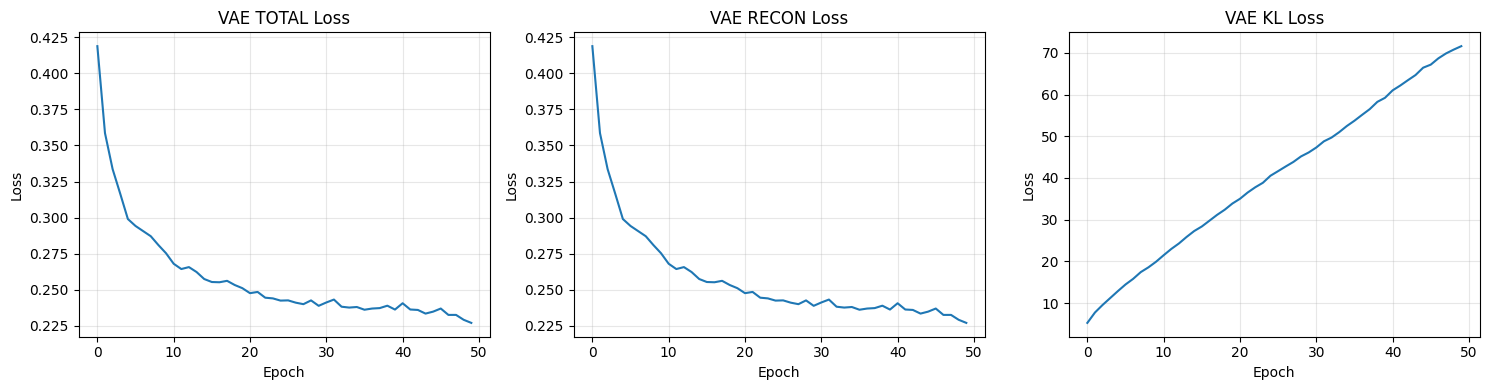

In [17]:
# Plot VAE training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, values) in zip(axes, vae_losses.items()):
    ax.plot(values)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'VAE {name.upper()} Loss')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config['save_dir']}/stage1_vae_loss.png", dpi=150)
plt.show()

In [18]:
# Save VAE model
torch.save(temporal_vae.state_dict(), f"{config['save_dir']}/stage1_vae.pt")
print(f"Saved VAE model to {config['save_dir']}/stage1_vae.pt")

Saved VAE model to Transformer-algorithm//stage1_vae.pt


---
## Stage 2: Decision Transformer for Offline Policy Learning

Learn return-conditioned policy using transformer architecture.

In [19]:
# =============================================================================
# STAGE 2: DECISION TRANSFORMER TRAINING
# =============================================================================

print("="*60)
print("STAGE 2: Decision Transformer Training")
print("="*60)

# Initialize Decision Transformer
decision_transformer = DecisionTransformer(
    state_dim=config['state_dim'],
    action_dim=config['action_dim'],
    d_model=config['dt_d_model'],
    nhead=config['dt_nhead'],
    num_layers=config['dt_num_layers'],
    max_seq_len=config['max_seq_len']
).to(device)

dt_trainer = DecisionTransformerTrainer(
    model=decision_transformer,
    lr=config['dt_lr']
)

print(f"DT Parameters: {sum(p.numel() for p in decision_transformer.parameters()):,}")

STAGE 2: Decision Transformer Training


TypeError: DecisionTransformer.__init__() got an unexpected keyword argument 'state_dim'

In [ ]:
# Prepare DT training data
def prepare_dt_batches(episodes, batch_size):
    """Prepare batched data for Decision Transformer."""
    states = np.stack([ep['states'] for ep in episodes])
    actions = np.stack([ep['actions'] for ep in episodes])
    returns = np.stack([ep['returns'] for ep in episodes])
    timesteps = np.stack([ep['timesteps'] for ep in episodes])
    masks = np.stack([ep['mask'] for ep in episodes])
    
    # Convert to tensors
    states_t = torch.FloatTensor(states).to(device)
    actions_t = torch.FloatTensor(actions).to(device)
    returns_t = torch.FloatTensor(returns).unsqueeze(-1).to(device)
    timesteps_t = torch.LongTensor(timesteps).to(device)
    masks_t = torch.FloatTensor(masks).to(device)
    
    n_batches = len(episodes) // batch_size
    batches = []
    
    for i in range(n_batches):
        idx = slice(i * batch_size, (i + 1) * batch_size)
        batches.append((
            states_t[idx], actions_t[idx], returns_t[idx],
            timesteps_t[idx], masks_t[idx]
        ))
    
    return batches

dt_batches = prepare_dt_batches(episodes, config['dt_batch_size'])
print(f"DT training batches: {len(dt_batches)}")

In [ ]:
# Decision Transformer Training Loop
dt_losses = []

for epoch in range(config['dt_epochs']):
    epoch_loss = 0
    
    for states_b, actions_b, returns_b, timesteps_b, masks_b in dt_batches:
        loss = dt_trainer.train_step(
            states_b, actions_b, returns_b, timesteps_b, masks_b
        )
        epoch_loss += loss
    
    epoch_loss /= len(dt_batches)
    dt_losses.append(epoch_loss)
    
    if epoch % 20 == 0 or epoch == config['dt_epochs'] - 1:
        print(f"Epoch {epoch:3d} | Loss: {epoch_loss:.4f}")

print("\nStage 2 Complete!")

In [ ]:
# Plot DT training curve
plt.figure(figsize=(10, 4))
plt.plot(dt_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Decision Transformer Training Loss')
plt.grid(True, alpha=0.3)
plt.savefig(f"{config['save_dir']}/stage2_dt_loss.png", dpi=150)
plt.show()

In [ ]:
# Save DT model
torch.save(decision_transformer.state_dict(), f"{config['save_dir']}/stage2_dt.pt")
print(f"Saved Decision Transformer to {config['save_dir']}/stage2_dt.pt")

---
## Stage 3: Conservative SAC + BC/CQL Fine-tuning

Final fine-tuning with offline safety constraints.

In [ ]:
# =============================================================================
# STAGE 3: CONSERVATIVE SAC TRAINING
# =============================================================================

print("="*60)
print("STAGE 3: Conservative SAC Training")
print("="*60)

# Initialize Conservative SAC Agent
sac_agent = ConservativeSACAgent(
    state_dim=config['state_dim'],
    action_dim=config['action_dim'],
    hidden_dim=config['sac_hidden_dim'],
    lr=config['sac_lr'],
    gamma=config['gamma'],
    cql_alpha=config['cql_alpha'],
    bc_alpha=config['bc_alpha']
).to(device)

print(f"SAC Parameters: {sum(p.numel() for p in sac_agent.actor.parameters()) + sum(p.numel() for p in sac_agent.critic_1.parameters()) * 2:,}")

In [ ]:
# SAC Training Loop
sac_losses = {
    'critic': [], 'actor': [], 'cql': [], 'bc': [], 'alpha': []
}

batch_size = config['sac_batch_size']
n_samples = len(train_data['states'])
unique_blocs = np.unique(train_data['bloc_nums'])

for epoch in range(config['sac_epochs']):
    epoch_losses = {k: 0 for k in sac_losses}
    n_batches = 0
    
    # Shuffle episodes
    np.random.shuffle(unique_blocs)
    
    for batch_start in range(0, len(unique_blocs), batch_size // 8):  # ~8 samples per episode
        batch_blocs = unique_blocs[batch_start:batch_start + batch_size // 8]
        batch_mask = np.isin(train_data['bloc_nums'], batch_blocs)
        
        if batch_mask.sum() < 16:  # Skip small batches
            continue
        
        batch_data = (
            state_t[batch_mask],
            next_state_t[batch_mask],
            action_t[batch_mask],
            next_action_t[batch_mask],
            reward_t[batch_mask],
            done_t[batch_mask]
        )
        
        loss_dict = sac_agent.update(batch_data)
        
        for k, v in loss_dict.items():
            if k in epoch_losses:
                epoch_losses[k] += v
        n_batches += 1
    
    for k in epoch_losses:
        epoch_losses[k] /= max(n_batches, 1)
        sac_losses[k].append(epoch_losses[k])
    
    if epoch % 20 == 0 or epoch == config['sac_epochs'] - 1:
        print(f"Epoch {epoch:3d} | Critic: {epoch_losses['critic']:.4f} | "
              f"Actor: {epoch_losses['actor']:.4f} | CQL: {epoch_losses['cql']:.4f} | "
              f"BC: {epoch_losses['bc']:.4f}")

print("\nStage 3 Complete!")

In [ ]:
# Plot SAC training curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_keys = ['critic', 'actor', 'cql', 'bc']
for ax, key in zip(axes.flatten(), plot_keys):
    ax.plot(sac_losses[key])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{key.upper()} Loss')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config['save_dir']}/stage3_sac_loss.png", dpi=150)
plt.show()

In [ ]:
# Save SAC model
torch.save({
    'actor': sac_agent.actor.state_dict(),
    'critic_1': sac_agent.critic_1.state_dict(),
    'critic_2': sac_agent.critic_2.state_dict(),
    'log_alpha': sac_agent.log_alpha.data
}, f"{config['save_dir']}/stage3_sac.pt")
print(f"Saved SAC model to {config['save_dir']}/stage3_sac.pt")

---
## Evaluation on Test Set

In [ ]:
# =============================================================================
# COMPREHENSIVE TEST EVALUATION
# =============================================================================

print("="*60)
print("TEST SET EVALUATION")
print("="*60)

# Use the trained SAC agent for evaluation
model = sac_agent

# Run comprehensive evaluation
results = do_test(
    model=model,
    Xtest=Xtest,
    actionbloctest=actionbloctest,
    bloctest=blocstest,
    Y90=Y90_test,
    SOFA=SOFA_test,
    reward_value=config['reward_value'],
    beat=config['beat'],
    save_dir=config['save_dir']
)

In [ ]:
# Visualize results
try:
    plot_ope_results(results, save_path=f"{config['save_dir']}/ope_results.png")
except Exception as e:
    print(f"Visualization error: {e}")

In [ ]:
# =============================================================================
# SUMMARY
# =============================================================================

print("\n" + "="*60)
print("TRAINING COMPLETE - SUMMARY")
print("="*60)

print(f"\n📁 Saved Files:")
print(f"   - {config['save_dir']}stage1_vae.pt")
print(f"   - {config['save_dir']}stage2_dt.pt")
print(f"   - {config['save_dir']}stage3_sac.pt")
print(f"   - {config['save_dir']}action_norm_stats.pkl")

print(f"\n📊 Final Metrics:")
print(f"   Q-value (Agent): {results.q_agent_mean:.4f} ± {results.q_agent_std:.4f}")
print(f"   Q-value (Phys):  {results.q_phys_mean:.4f} ± {results.q_phys_std:.4f}")
print(f"   WIS Estimate:    {results.wis_estimate:.4f} [{results.wis_ci_lower:.4f}, {results.wis_ci_upper:.4f}]")
print(f"   ESS Ratio:       {results.ess_ratio*100:.1f}%")
print(f"   Action MSE:      {results.action_mse:.4f}")
print(f"   Action Corr:     {results.action_correlation:.4f}")

elapsed = time.perf_counter() - start
print(f"\n⏱️ Total Training Time: {elapsed/60:.1f} minutes")

---
## Backward Compatibility: TransformerAgent Wrapper

In [ ]:
# =============================================================================
# ALTERNATIVE: USE UNIFIED ClinicalRLAgent
# =============================================================================

# For a unified three-stage pipeline in one object:
# clinical_agent = ClinicalRLAgent(
#     state_dim=config['state_dim'],
#     action_dim=config['action_dim'],
#     ...
# )
# clinical_agent.train_stage1(episodes, config['vae_epochs'])
# clinical_agent.train_stage2(episodes, config['dt_epochs'])
# clinical_agent.train_stage3(transitions, config['sac_epochs'])

# For backward compatibility with existing code:
# transformer_agent = TransformerAgent(...)
# Works exactly like original EDAC interface

print("Notebook complete! Use TransformerAgent for EDAC-compatible interface.")

In [ ]:
# device = 'cpu'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

In [ ]:
import torch
print(torch.version.cuda)  # Pastikan tidak None
print(torch.backends.cudnn.enabled)  # Harus True

In [ ]:
# =========================== small function===============================
from scipy.stats import zscore, rankdata

def my_zscore(x):
    return zscore(x, ddof=1), np.mean(x, axis=0), np.std(x, axis=0, ddof=1)

## Load Data dan Preprocessing

In [ ]:
seed = 42

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
if __name__ == '__main__':
    start = time.perf_counter()
    with open('../step_4_start_mimiciv_try.pkl', 'rb') as file:
        MIMICtable = pickle.load(file)

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    
    ##################### Pengaturan parameter model##############################
    # Training Parameters
    num_epoch = 101
    gamma = 0.99
    beat1 = 0
    beat2 = 0.6
    beta3 = 0.3
    lr = 3e-4
    reward_value = 24
    beta = [beat1, beat2, beta3]
    
    icustayidlist = MIMICtable['stay_id']
    # list of unique icustayids from MIMIC unique icustayid list
    icuuniqueids = np.unique(icustayidlist)
    reformat5 = MIMICtable.values.copy()
    print('####  generated state  ####')

    # -----------------------Filtered features = 37--------------------------------
    colnorm = ['SOFA', 'age', 'Weight_kg', 'GCS', 'HR', 'SysBP', 'MeanBP', 'DiaBP', 'RR', 'Temp_C',
               'Sodium', 'Chloride', 'Glucose', 'Calcium', 'Hb', 'WBC_count', 'Platelets_count',
               'PTT', 'PT', 'Arterial_pH', 'paO2', 'paCO2', 'HCO3', 'Arterial_lactate', 'Shock_Index',
               'PaO2_FiO2', 'cumulated_balance', 'CO2_mEqL', 'Ionised_Ca']
    # 8 indicators
    collog = ['SpO2', 'BUN', 'Creatinine', 'SGOT',
              'Total_bili', 'INR', 'input_total', 'output_total']

    colnorm = np.where(np.isin(MIMICtable.columns, colnorm))[0]
    collog = np.where(np.isin(MIMICtable.columns, collog))[0]

    scaleMIMIC = np.concatenate([zscore(reformat5[:, colnorm], ddof=1),
                                 zscore(np.log(0.1 + reformat5[:, collog]), ddof=1)], axis=1)

    train = np.load('train_mimiciv.npy')
    validat = np.load('validation_mimiciv.npy')
    test = np.load('test_mimiciv.npy')

    Xvalidat = scaleMIMIC[validat, :]
    blocsvalidat = reformat5[validat, 0]
    ptidvalidat = reformat5[validat, 1]

    Xtrain = scaleMIMIC[train, :]
    Xtest = scaleMIMIC[test, :]
    blocstrain = reformat5[train, 0]  # Serial number
    bloctest = reformat5[test, 0]
    ptidtrain = reformat5[train, 1]  # Patient number
    ptidtest = reformat5[test, 1]

    RNNstate = Xtrain
    
    print('####  Generating Actions  ####')
    # --- Ambil kolom indeks IV dan vasopressor ---
    iol = MIMICtable.columns.get_loc('input_4hourly')      # IV fluid column
    vcl = MIMICtable.columns.get_loc('max_dose_vaso')      # Vasopressor column

    # Ambil nilai mentah (raw)
    iv_raw = reformat5[:, iol].reshape(-1, 1)
    vaso_raw = reformat5[:, vcl].reshape(-1, 1)

    # Lakukan log1p transform (lebih aman untuk data dengan nol)
    iv_log = np.log1p(iv_raw)
    vaso_log = np.log1p(vaso_raw)

    # Hitung mean dan std di domain log
    mean_log_iv = iv_log.mean()
    std_log_iv = iv_log.std(ddof=1)

    mean_log_vaso = vaso_log.mean()
    std_log_vaso = vaso_log.std(ddof=1)

    # Normalisasi dengan z-score
    iv_norm = (iv_log - mean_log_iv) / std_log_iv
    vaso_norm = (vaso_log - mean_log_vaso) / std_log_vaso

    # Gabungkan sebagai continuous action
    continuous_actions = np.concatenate([iv_norm, vaso_norm], axis=1)

    # Simpan untuk inverse transform saat inference
    norm_stats = {
        "mean_log_iv": float(mean_log_iv),
        "std_log_iv": float(std_log_iv),
        "mean_log_vaso": float(mean_log_vaso),
        "std_log_vaso": float(std_log_vaso)
    }
    with open('action_norm_stats_transformer.pkl', 'wb') as f:
        pickle.dump(norm_stats, f)

    # Split actions untuk train/valid/test
    actionbloctrain = continuous_actions[train]
    actionblocvalidat = continuous_actions[validat]
    actionbloctest = continuous_actions[test]

    # =================incentives============================
    print('####  Generate Rewards  ####')
    outcome = 9
    Y90 = reformat5[train, outcome]
    reward_value = 24
    r = np.array([reward_value, -reward_value]).reshape(1, -1)
    r2 = r * (2 * (1 - Y90.reshape(-1, 1)) - 1)

    SOFA = reformat5[train, 57]
    R3 = r2[:, 0]
    R4 = (R3 + reward_value) / (2 * reward_value)
    c = 0
    bloc_max = max(blocstrain)

    print('####  Generate trajectory  ####')
    statesize = int(RNNstate.shape[1])
    states = np.zeros((np.floor(RNNstate.shape[0] * 1.2).astype('int64'), statesize))
    actions = np.zeros((np.floor(RNNstate.shape[0] * 1.2).astype('int64'), 2), dtype=np.float32)
    next_actions = np.zeros((np.floor(RNNstate.shape[0] * 1.2).astype('int64'), 2), dtype=np.float32)
    rewards = np.zeros((np.floor(RNNstate.shape[0] * 1.2).astype('int64'), 1))
    next_states = np.zeros((np.floor(RNNstate.shape[0] * 1.2).astype('int64'), statesize))
    done_flags = np.zeros((np.floor(RNNstate.shape[0] * 1.2).astype('int64'), 1))
    bloc_num = np.zeros((np.floor(RNNstate.shape[0] * 1.2).astype('int64'), 1))
    blocnum1 = 1

    bloc_num_reward = 0
    for i in range(RNNstate.shape[0] - 1):
        states[c] = RNNstate[i, :]
        actions[c] = actionbloctrain[i]
        bloc_num[c] = blocnum1
        if (blocstrain[i + 1] == 1):
            next_states1 = np.zeros(statesize)
            next_actions1 = -1
            done_flags1 = 1
            blocnum1 = blocnum1 + 1
            bloc_num_reward += 1
            reward1 = -beat1 * (SOFA[i]) + R3[i]
            bloc_num_reward = 0
        else:
            next_states1 = RNNstate[i + 1, :]
            next_actions1 = actionbloctrain[i + 1]
            done_flags1 = 0
            blocnum1 = blocnum1
            reward1 = - beat2 * (SOFA[i + 1] - SOFA[i])
            bloc_num_reward += 1
        next_states[c] = next_states1
        next_actions[c] = next_actions1
        rewards[c] = reward1
        done_flags[c] = done_flags1
        c = c + 1
        
    states[c] = RNNstate[c, :]
    actions[c] = actionbloctrain[c]
    bloc_num[c] = blocnum1

    next_states1 = np.zeros(statesize)
    next_actions1 = -1
    done_flags1 = 1
    blocnum1 = blocnum1 + 1
    bloc_num_reward += 1
    reward1 = -beat1 * (SOFA[c]) + R3[c]

    bloc_num_reward = 0
    next_states[c] = next_states1
    next_actions[c] = next_actions1
    rewards[c] = reward1
    done_flags[c] = done_flags1
    c = c + 1

    bloc_num[c] = blocnum1
    bloc_num = bloc_num[:c, :]
    states = states[: c, :]
    next_states = next_states[: c, :]
    actions = actions[: c, :]
    next_actions = next_actions[: c, :]
    rewards = rewards[: c, :]
    done_flags = done_flags[: c, :]
    bloc_num = np.squeeze(bloc_num)
    actions = np.squeeze(actions)
    rewards = np.squeeze(rewards)
    done_flags = np.squeeze(done_flags)
    
    batch_size = 16
    state = torch.FloatTensor(states).to(device)
    next_state = torch.FloatTensor(next_states).to(device)
    action = torch.FloatTensor(actions).to(device)
    next_action = torch.FloatTensor(next_actions).to(device)
    reward = torch.FloatTensor(rewards).to(device)
    done = torch.FloatTensor(done_flags).to(device)
    SOFAS = torch.LongTensor(SOFA).to(device)
    batchs = (state, next_state, action, next_action, reward, done, bloc_num, SOFAS)

    # =================Training model, master cycle==================
    Y90_validat = reformat5[validat, outcome]
    SOFA_validat = reformat5[validat, 57]

## Training Transformer Model

In [ ]:
# Training Model dengan Transformer Architecture
# Parameters: d_model=128, nhead=4, num_layers=3
model = TransformerAgent(
    state_dim=37, 
    action_dim=2,
    d_model=128,
    nhead=4,
    num_layers=3,
    dim_feedforward=256
)

record_loss_z = []
record_phys_q = []
record_agent_q = []
best_mean_agent_q = -float('inf')
save_dir = 'Transformer-algorithm/'
os.makedirs(save_dir, exist_ok=True)

for epoch in range(num_epoch):
    record = model.train(batchs, epoch)
    record_loss_z.append(record)

    record_a = np.array(record_loss_z)
    record_b = np.mean(record_a, axis=1)

    # --------------------Validation Sets, Evaluation-----------------------
    uids = np.unique(bloc_num)
    batch_s = ptidvalidat
    batch_user = np.isin(bloc_num, batch_s)
    state_user = state[batch_user, :]
    action_user = action[batch_user]
    next_state_user = next_state[batch_user, :]
    next_action_user = next_action[batch_user]
    reward_user = reward[batch_user]
    done_user = done[batch_user]

    batch = (state_user, next_state_user, action_user,
             next_action_user, reward_user, done_user)

    # Evaluasi menggunakan Transformer model
    q_phys, q_agent, agent_action, phys_action, agent_log_prob, action_mean, action_std = do_eval(
        model, batch)

    mean_agent_q = torch.mean(q_agent).item()
    mean_phys_q = torch.mean(q_phys).item()

    print(f'Epoch {epoch} - Mean agent Q: {mean_agent_q:.4f}, Mean phys Q: {mean_phys_q:.4f}')

    record_phys_q.append(mean_phys_q)
    record_agent_q.append(mean_agent_q)

    if mean_agent_q > best_mean_agent_q:
        best_mean_agent_q = mean_agent_q
        best_model_save_path = os.path.join(save_dir, 'best_model_transformer.pt')
        torch.save({
            'actor_state_dict': model.actor.state_dict(),
            'critic_1_state_dict': model.critic_1.state_dict(),
            'critic_2_state_dict': model.critic_2.state_dict(),
            'best_mean_agent_q': best_mean_agent_q
        }, best_model_save_path)
        print(f'New best model saved with mean agent Q: {best_mean_agent_q:.4f}')

    if epoch % 10 == 0:
        print('Sample agent actions:', agent_action[:5])
        print('Sample physician actions:', phys_action[:5])

## Visualisasi Training

In [ ]:
# ====================== Visualisasi ======================
x_length_list = list(range(len(record_b)))
plt.figure(figsize=(10, 6))
plt.title('Training Loss - Transformer Model')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(x_length_list, record_b)
plt.grid(True)
np.save(os.path.join(save_dir, 'loss.npy'), record_b)
plt.show()

In [ ]:
# Convert and save record_agent_q
record_agent_q_np = [
    q.detach().cpu().numpy() if isinstance(q, torch.Tensor) else q
    for q in record_agent_q
]
record_agent_q_np = np.array(record_agent_q_np)
agent_length_list = list(range(len(record_agent_q_np)))

# Convert and save record_phys_q
record_phys_q_np = [
    q.detach().cpu().numpy() if isinstance(q, torch.Tensor) else q
    for q in record_phys_q
]
record_phys_q_np = np.array(record_phys_q_np)
phys_length_list = list(range(len(record_phys_q_np)))

# Plot Q values
plt.figure(figsize=(10, 6))
plt.plot(agent_length_list, record_agent_q_np, label='Agent Q', linewidth=2)
plt.plot(phys_length_list, record_phys_q_np, label='Physician Q', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Mean Q value")
plt.title('Q-Value Comparison - Transformer Model')
plt.legend()
plt.grid(True)

np.save(os.path.join(save_dir, 'mean_agent_q.npy'), record_agent_q_np)
np.save(os.path.join(save_dir, 'mean_phys_q.npy'), record_phys_q_np)
plt.show()

## Testing dan Evaluasi

In [ ]:
# =================测试集，评估test set================================================================
Y90_test = reformat5[test, outcome]
SOFA_test = reformat5[test, 57]
do_test(model, Xtest, actionbloctest, bloctest, Y90_test, SOFA_test, reward_value, beta)

elapsed = (time.perf_counter() - start)
print(f"Time used: {elapsed:.2f} seconds")
plt.show()

## Load Model untuk Inference

In [ ]:
def load_transformer_model(model_path, state_dim, action_dim, d_model=128, nhead=4, num_layers=3):
    """
    Load trained Transformer model dari checkpoint.
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")

    # Inisialisasi model TransformerAgent
    model = TransformerAgent(
        state_dim=state_dim, 
        action_dim=action_dim,
        d_model=d_model,
        nhead=nhead,
        num_layers=num_layers
    )

    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=torch.device('cpu'))

    # Load state_dict ke masing-masing komponen model
    model.actor.load_state_dict(checkpoint['actor_state_dict'])
    model.critic_1.load_state_dict(checkpoint['critic_1_state_dict'])
    model.critic_2.load_state_dict(checkpoint['critic_2_state_dict'])

    print(f"Model loaded successfully from {model_path}")
    print(f"Best mean agent Q from training: {checkpoint['best_mean_agent_q']}")

    return model

In [ ]:
# Example: Load best model
# model_loaded = load_transformer_model('Transformer-algorithm/best_model_transformer.pt', 37, 2)

## Inverse Transform untuk Actions

In [ ]:
with open('action_norm_stats_transformer.pkl', 'rb') as f:
    stats = pickle.load(f)
    
def inverse_transform_actions(actions_norm, stats):
    """
    Inverse transform normalized actions back to original scale.
    
    Parameters:
    - actions_norm: normalized actions [N, 2]
    - stats: dictionary containing normalization statistics
    
    Returns:
    - actual_actions: actions in original scale [N, 2]
    """
    iv_log = actions_norm[:, 0] * stats['std_log_iv'] + stats['mean_log_iv']
    vaso_log = actions_norm[:, 1] * stats['std_log_vaso'] + stats['mean_log_vaso']

    iv = np.expm1(iv_log)
    vaso = np.expm1(vaso_log)

    return np.stack([iv, vaso], axis=1)

In [ ]:
# Example: Get action from model and convert to original scale
# state_sample = torch.tensor(states[20], dtype=torch.float32).unsqueeze(0)
# action_normalized = model.get_action(state_sample)
# actual_actions = inverse_transform_actions(action_normalized, stats)
# print(f"IV Fluid: {actual_actions[0, 0]:.2f}, Vasopressor: {actual_actions[0, 1]:.4f}")